## Playing around with attendance data

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

cities = pd.read_csv("../data/cities.csv")

# I'm going to assume "trip" == "event"
sites = pd.read_csv("../data/sites.csv", index_col="siteId")
cities = pd.read_csv("../data/cities.csv")
events = pd.read_csv("../data/events.csv")

eventHistory = pd.merge(sites, events, on="siteId")
eventHistory = pd.merge(eventHistory, cities, on="city")



# Remove nans for city and site type 
eventHistory = eventHistory.dropna(subset=["city", "siteType"])

# Split multi-valued items
eventHistory["siteType"] = eventHistory["siteType"].apply(lambda st : np.array(st.split(";")) )
eventHistory["siteTypePretty"] = eventHistory["siteType"].apply(lambda st : ", ".join(st) )

display(eventHistory)



,siteId,siteName,city,siteType,dow,startTime,endTime,EventDuration,wom,Notes,date,footTraffic,lat,long,pop,svi,siteTypePretty
0,12,Community Dinner,Alger,[Charitable Meal\n],Wednesday,1630.0,1830.0,2.0,4,Fourth Wednesday of each month,2024-08-27,2,40.709722,-83.844167,837,0.594200,Charitable Meal\n
1,12,Community Dinner,Alger,[Charitable Meal\n],Wednesday,1630.0,1830.0,2.0,4,Fourth Wednesday of each month,2024-09-24,13,40.709722,-83.844167,837,0.594200,Charitable Meal\n
2,12,Community Dinner,Alger,[Charitable Meal\n],Wednesday,1630.0,1830.0,2.0,4,Fourth Wednesday of each month,2024-10-22,0,40.709722,-83.844167,837,0.594200,Charitable Meal\n
3,12,Community Dinner,Alger,[Charitable Meal\n],Wednesday,1630.0,1830.0,2.0,4,Fourth Wednesday of each month,2024-11-20,3,40.709722,-83.844167,837,0.594200,Charitable Meal\n
4,12,Community Dinner,Alger,[Charitable Meal\n],Wednesday,1630.0,1830.0,2.0,4,Fourth Wednesday of each month,2025-01-28,8,40.709722,-83.844167,837,0.594200,Charitable Meal\n
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,31,Christian Corner,Lima,[Food bank],NaN,NaN,NaN,NaN,NaN,NaN,2025-04-01,1,40.746389,-84.123333,35579,0.923333,Food bank
125,31,Christian Corner,Lima,[Food bank],NaN,NaN,NaN,NaN,NaN,NaN,2025-05-06,4,40.746389,-84.123333,35579,0.923333,Food bank
126,32,Alger Library,Alger,[Library],NaN,NaN,NaN,NaN,NaN,NaN,2024-11-14,5,40.709722,-83.844167,837,0.594200,Library
127,33,Delphos Senior Center,Delphos,[Senior community],NaN,NaN,NaN,NaN,NaN,NaN,2025-02-05,5,40.861111,-84.350000,7117,0.562500,Senior community


## Helper functions

In [41]:
def remove_special_events(events):

    no_special_events_mask = np.logical_not(events["siteType"].apply(lambda t : (t == "Special Event").all()))
    return events.loc[no_special_events_mask,:]



def plot_site_scatter(events, filter_value=None, legend=True, group_attr="siteName", x_var="pop"):

    events = remove_special_events(events)

    if filter_value != None: 
        site_type_mask = events["siteType"].apply(lambda t : (t == filter_value).any())
        events = events.loc[site_type_mask,:]

    site_set = set(events[group_attr])

    fig, ax = plt.subplots()

    for site in site_set:
        x = events.loc[events[group_attr] == site, x_var]
        y = events.loc[events[group_attr] == site,"footTraffic"]

        current_city = events.loc[events[group_attr] == site,"city"].values[0]

        label = f"{site}"
        ax.scatter(x, y, label=label)

    if legend:
        plt.legend(loc="center left", bbox_to_anchor=(1,0.5))

    if filter_value is not None:
        plt.title(f"Expected attendance at {filter_value} sites")
    else:
        plt.title(f"Expected attendance across all sites")

    ax.set_xlabel(x_var)
    ax.set_ylabel("footTraffic")
    fig.set_size_inches(8, 5)

    return ax

## Examining attenance as a function of population and site type
_Reflections_: It doesn't seem that population is a big determinant of expected attendance 

<Axes: title={'center': 'Expected attendance at Library sites'}, xlabel='pop', ylabel='footTraffic'>

<Axes: title={'center': 'Expected attendance at Thrift store sites'}, xlabel='pop', ylabel='footTraffic'>

C:\Users\i-kropp\AppData\Local\Temp\ipykernel_24204\3014280953.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left", bbox_to_anchor=(1,0.5))


<Axes: title={'center': 'Expected attendance at Charitable Meal sites'}, xlabel='pop', ylabel='footTraffic'>

<Axes: title={'center': 'Expected attendance at Senior community sites'}, xlabel='pop', ylabel='footTraffic'>

<Axes: title={'center': 'Expected attendance at Gym sites'}, xlabel='pop', ylabel='footTraffic'>

<Axes: title={'center': 'Expected attendance at Church sites'}, xlabel='pop', ylabel='footTraffic'>

<Axes: title={'center': 'Expected attendance at Food pantry sites'}, xlabel='pop', ylabel='footTraffic'>

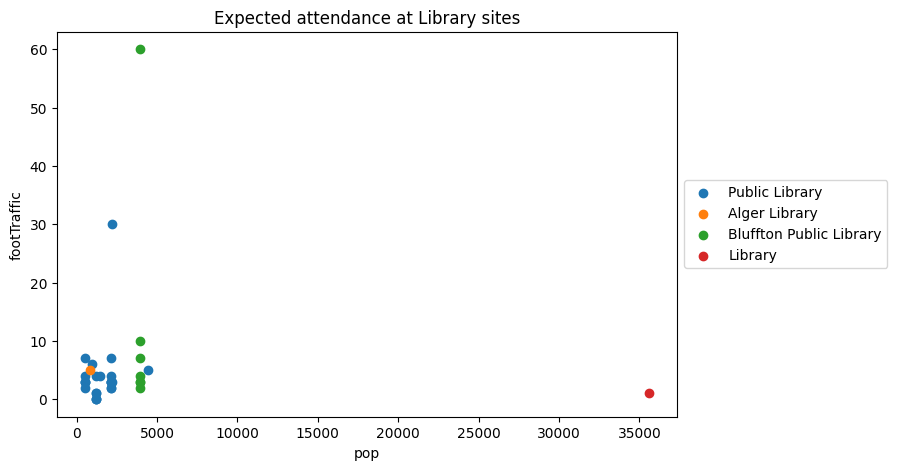

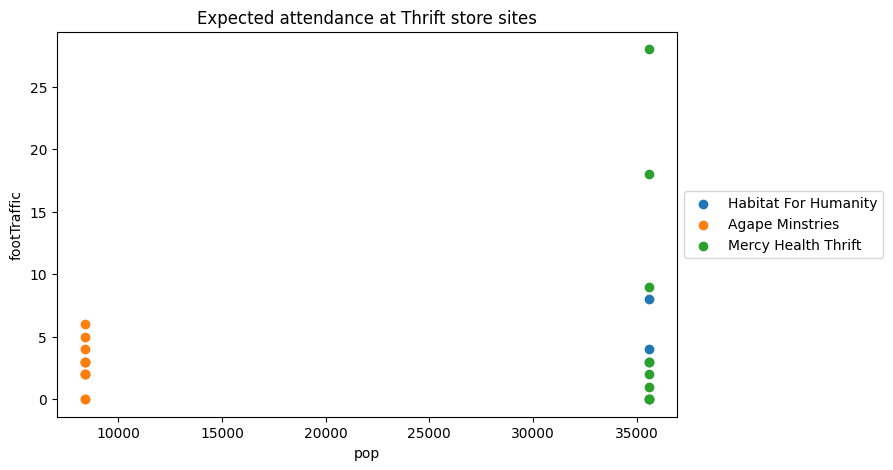

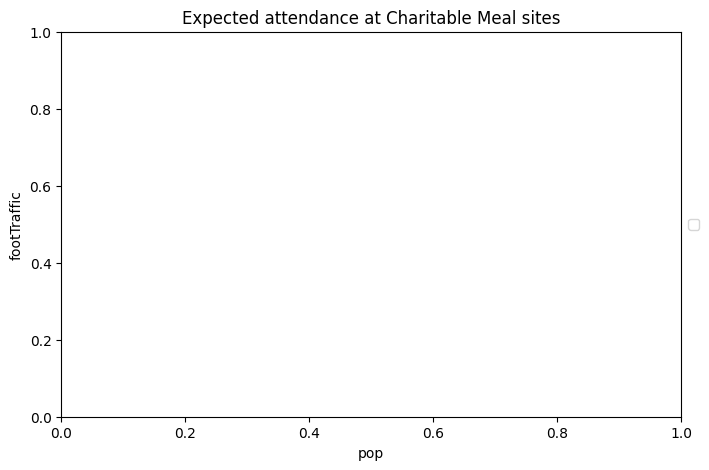

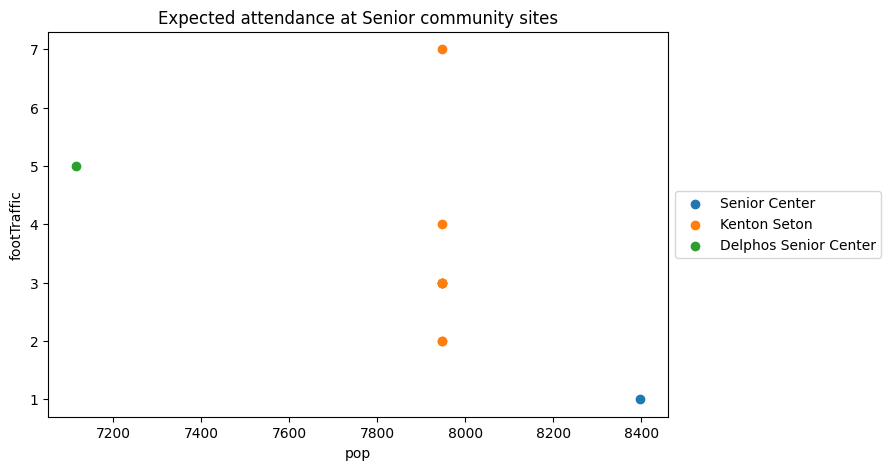

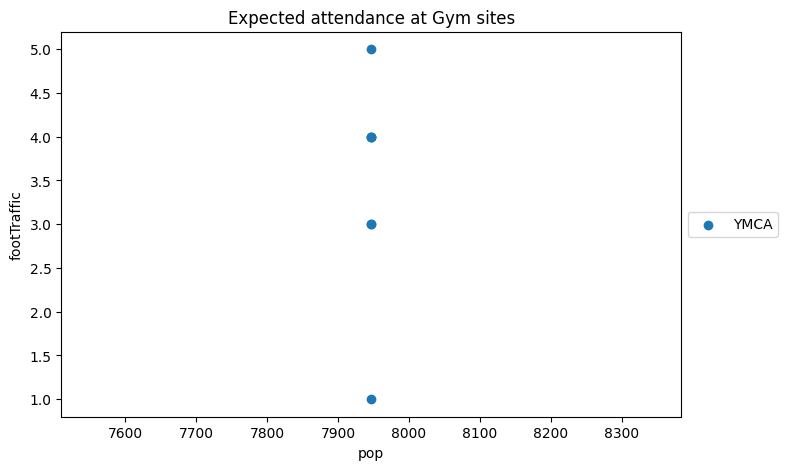

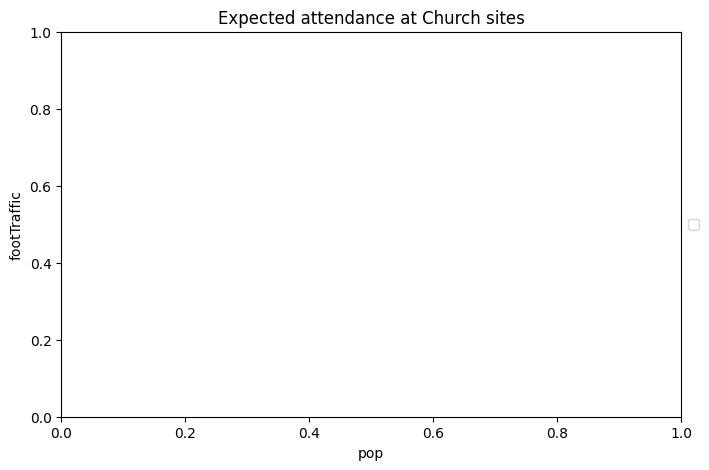

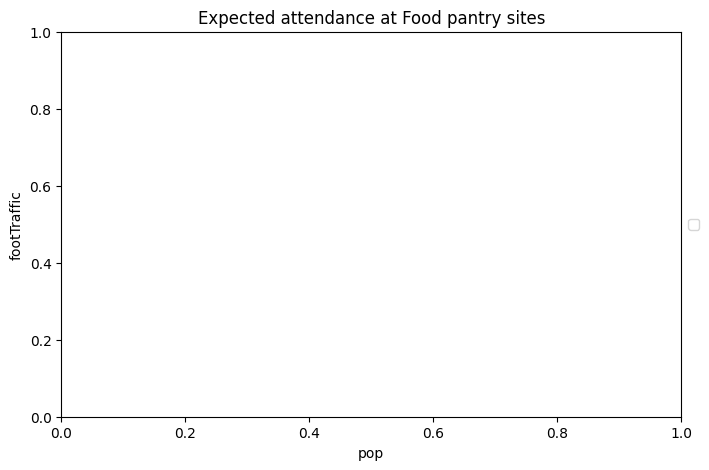

In [42]:
ax = plot_site_scatter(eventHistory, filter_value="Library")
display(ax)

ax = plot_site_scatter(eventHistory, filter_value="Thrift store")
display(ax)

ax = plot_site_scatter(eventHistory, filter_value='Charitable Meal')
display(ax)

ax = plot_site_scatter(eventHistory, filter_value="Senior community")
display(ax)

ax = plot_site_scatter(eventHistory, filter_value="Gym")
display(ax)

ax = plot_site_scatter(eventHistory, filter_value="Church")
display(ax)

ax = plot_site_scatter(eventHistory, "Food pantry")
display(ax)

## Examining attendance as a function of population
_Reflections:_ It looks like population really isn't a big determinant of expected attendance 

<Axes: title={'center': 'Expected attendance across all sites'}, xlabel='Population of city', ylabel='footTraffic'>

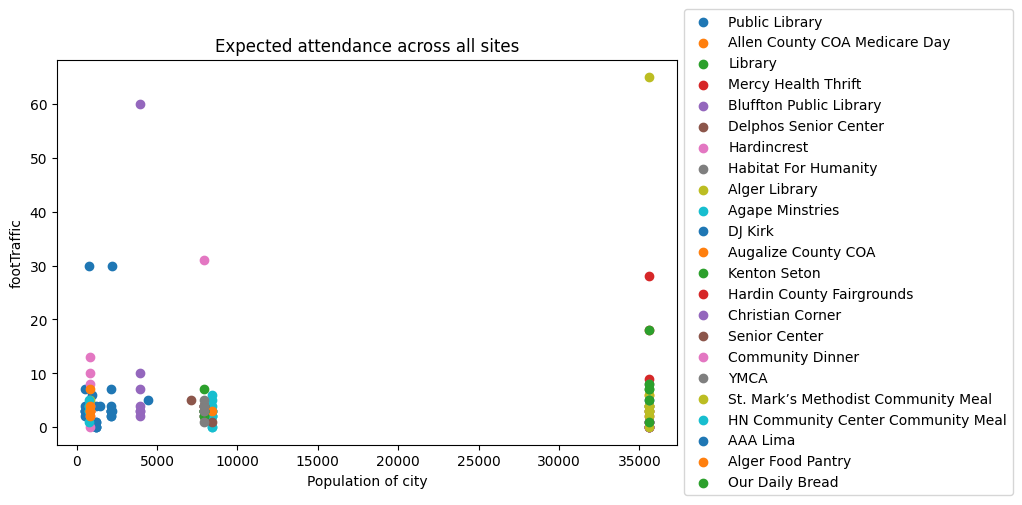

In [43]:
events_no_special = remove_special_events(eventHistory)
ax = plot_site_scatter(events_no_special, legend=True, group_attr="siteName")
ax.set_xlabel("Population of city")
display(ax);

Text(0.5, 0, 'Population of city')

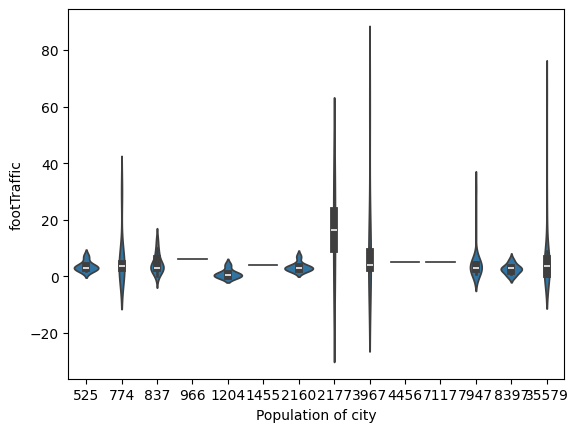

In [44]:
import seaborn as sns

ax = sns.violinplot(data=events_no_special, x="pop", y="footTraffic")
ax.set_xlabel("Population of city")

## Examining event type versus attendance

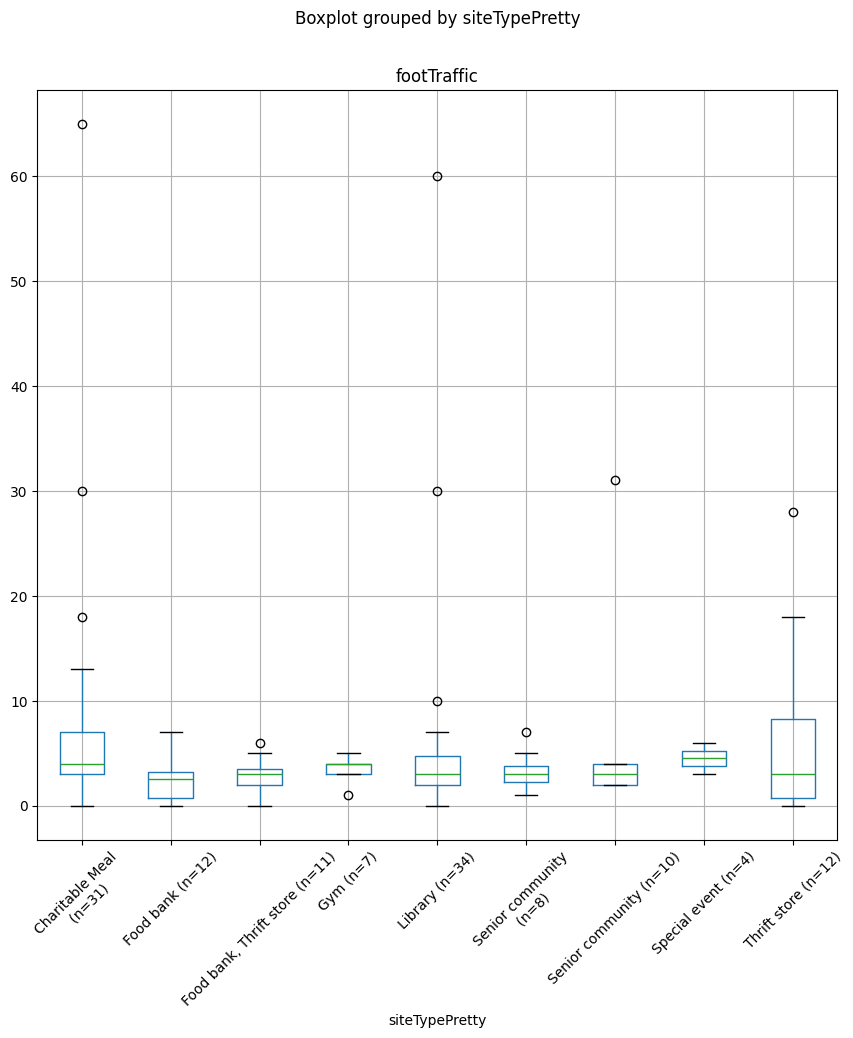

In [45]:

counts = events_no_special['siteTypePretty'].value_counts()
new_labels = [f"{label} (n={counts[label]})" for label in counts.index]
ax = events_no_special.boxplot(column="footTraffic", by="siteTypePretty", figsize=(10,10), rot=45)
new_labels.sort()
ax.set_xticklabels(new_labels);


## Examining city versus attendance

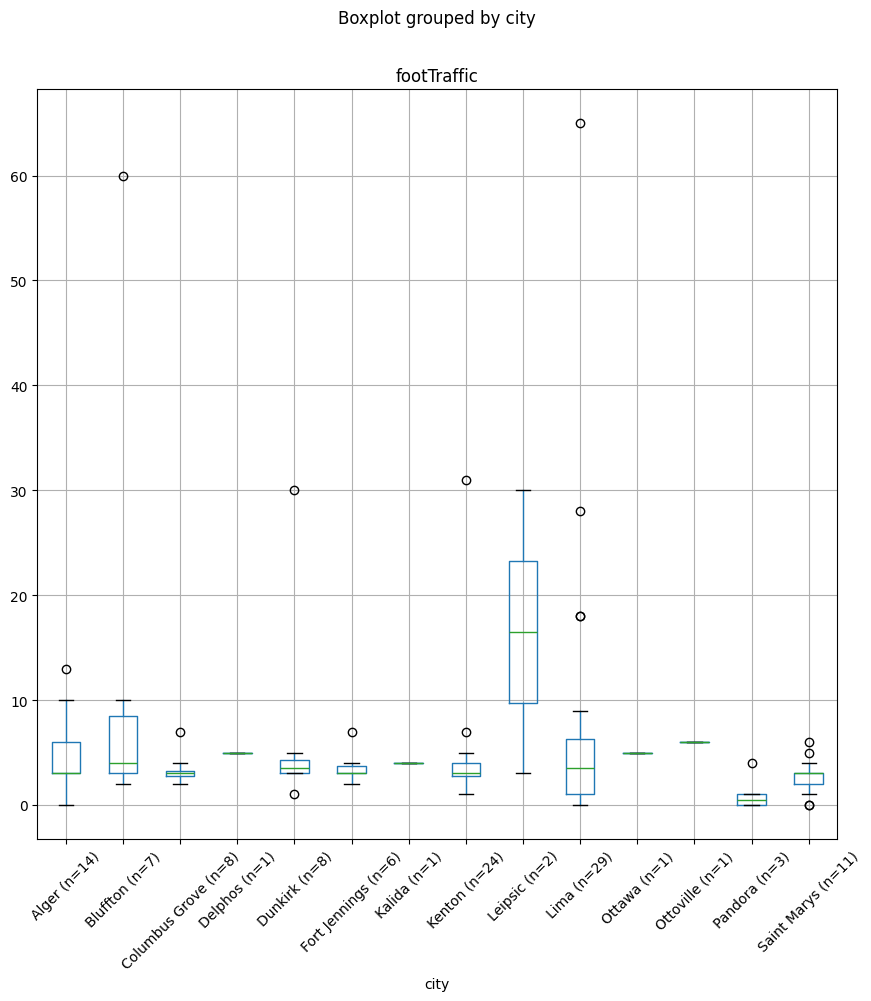

In [46]:
counts = events_no_special.loc[events_no_special["footTraffic"] > 0, 'city'].value_counts()
new_labels = [f"{label} (n={counts[label]})" for label in counts.index]
new_labels.sort()
ax = events_no_special.boxplot(column="footTraffic", by="city", figsize=(10,10),rot=45)
ax.set_xticklabels(new_labels);

## Corellation analysis
... yes I realize the city values and the types doesn't make much sense. But meh. 
_Reflection:_ But!! Population size and foot traffic are very uncorrelated 

In [ ]:
def dictionize_df(df, attr): 
    discrete_vals = set(df.loc[:,attr].values)
    dictionary = {value: number for (number, value) in enumerate(discrete_vals)}
    return dictionary


city_dict = dictionize_df(eventHistory, "city")
loca_dict = dictionize_df(eventHistory, "siteName")
type_dict = dictionize_df(eventHistory, "siteTypePretty")

attributes = ["footTraffic", "siteTypePretty", "pop", "city", "siteName"]
numbery_events = events_no_special.loc[:,attributes]
numbery_events = numbery_events.replace({"city" : city_dict, 
                                         "siteName": loca_dict,
                                         "siteTypePretty" : type_dict})


corr_mat = numbery_events.corr()
display(corr_mat)

plt.matshow(corr_mat)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16);
plt.show()



KeyError: "['Foot traffic'] not in index"